In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os
from langchain_groq import ChatGroq
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langchain_core.prompts import PromptTemplate
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [25]:
load_dotenv()


True

In [17]:
model= ChatGoogleGenerativeAI(model='gemini-3.8-flash')

In [47]:
print(model.invoke('hi how are you').content)

[{'type': 'text', 'text': "Hello! I'm doing well, thank you for asking. How are you doing today? How can I help you?", 'extras': {'signature': 'ErwGCrkGAWkUfROohCushNjDbGPPhCjLYOKERzRIMyT7SdRqwPM89GIuN2SHdq8U5nRw/L8bzvqf+tvfzQ/TsCkIlFvAX5axDKbbzCVi/LDJAT6cuxjqHNHCqqTvVnlnSfLBCqrBBdN0GI1gVIdiYl8skJw8ae6DolvVr61FW1dsG1yu1gUpkZL4JPapcRCZQk02uPDeCrt3shAlDIAJU3Y65dJaMgwr6IpLXUg6+WH2PeCr3DYak0/+H+X+TWfzThvnDDTdqssxMOnUdOPSsacXyJ4RAkUlHSM2TPonM+TeQFYPerm2W7ngHNf1vnD75pEaicPRv+FM9Ycd1pwCaQ7Jj2vmv0AZsJKXzhElms2NZZyJuEmeRm8bmxMkPmnOXAJmjCkvjObUfO9cv+9C/1WM7TOVJaZHwRyrUkZ1CEg/Lie9+BDv8MO8efIMZGKy1JhwdyIh9+PcIfO2a3bzcP6wtMEEj5YC+pNdUJEcDffadywGxi0BOcBYMHb4OzTIbaE8uoyaHfTS5F+snDMINjYKuadPrlyn5vGeAQqywvKL00j85/arZvm6W20ZM/+hNY0/XYAXmQA6MmGD2IxLAXuN6Mp/TnET2bfw8zOtgnbzF4QNuJ4ni7rXHYnLjyXksfu0L8547LJ48obKCUNVi6CPJX7VgypAatqLYxJ6NTFr/Vwji4YxciJlXGaCYuF+dYZ8THy8xDcneFcF08datg4jPgmg+I2pzoPB2xyYolekrx5rpa56JP7xcpK+PIof7gOkYK3JOD2WvpiHZ3IEmz+//xmT51fFh7OKA8Grr/PyL1h5iaw/dt788Ag8wLnd38QQBhna/2irR5V0CtOG40Hs

In [ ]:
[
:
    {
        'type': 'text',
        'text': "Hello! I'm doing well, thank you for asking. How are you doing today? How can I help you?", 
        'extras': {'output_token_details': {'reasoning': 180}}  # Wrapped in a nested dictionary
    }
]



In [36]:
content[0]['text']

"Hello! I'm doing well, thank you for asking. How are you doing today? How can I help you?"

In [18]:
class BlogState(TypedDict):
     
     title:str
     outline:str
     blog: str



In [59]:
def create_blog(state:BlogState)->BlogState:
        
        outline= state['outline']
        title=   state['outline']
        prompt= f'generate a short blog on following {title} outline- {outline}'
        
        
        blog= model.invoke(prompt).content[0]['text']
        
        state['blog']=blog

        return state

In [60]:
def create_outline(state: BlogState)-> BlogState:
        
        title= state['title']
        prompt =f'create a outline for the topic: {title}'

        outline= model.invoke(prompt).content[0]['text']

        state['outline']= outline


        return state

In [62]:
graph=StateGraph(BlogState)


graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)


graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)


workflow= graph.compile()




In [63]:
initial_state={'title':'Indian Cricket Team'}

final_state= workflow.invoke(initial_state)

print(final_state)

{'title': 'Indian Cricket Team', 'outline': 'Here is a comprehensive and structured outline on the **Indian Cricket Team**, suitable for an essay, presentation, research paper, or documentary.\n\n---\n\n### **I. Introduction**\n*   **A. Overview:** The governing body (Board of Control for Cricket in India – BCCI), team identity (The "Men in Blue"), and team emblem.\n*   **B. Global Standing:** India’s position as a dominant force in modern international cricket across all three formats (Test, ODI, T20I).\n*   **C. Thesis/Core Theme:** The transformation of the Indian cricket team from international underdogs to a global powerhouse, reflecting the nation\'s socio-economic and cultural evolution.\n\n---\n\n### **II. Historical Evolution**\n*   **A. Early Beginnings (1932–1970):**\n    *   India\'s first official Test match (1932 at Lord’s under CK Nayudu).\n    *   Post-independence struggles and early breakthrough victories (First Test win vs. England in 1952).\n*   **B. The Golden Age 

In [64]:
final_state['outline']

'Here is a comprehensive and structured outline on the **Indian Cricket Team**, suitable for an essay, presentation, research paper, or documentary.\n\n---\n\n### **I. Introduction**\n*   **A. Overview:** The governing body (Board of Control for Cricket in India – BCCI), team identity (The "Men in Blue"), and team emblem.\n*   **B. Global Standing:** India’s position as a dominant force in modern international cricket across all three formats (Test, ODI, T20I).\n*   **C. Thesis/Core Theme:** The transformation of the Indian cricket team from international underdogs to a global powerhouse, reflecting the nation\'s socio-economic and cultural evolution.\n\n---\n\n### **II. Historical Evolution**\n*   **A. Early Beginnings (1932–1970):**\n    *   India\'s first official Test match (1932 at Lord’s under CK Nayudu).\n    *   Post-independence struggles and early breakthrough victories (First Test win vs. England in 1952).\n*   **B. The Golden Age of Spin and Technique (1970s):**\n    *   Th

In [66]:
final_state['blog']

"# From Underdogs to Global Giants: The Unstoppable Rise of the Indian Cricket Team\n\nIn India, cricket isn’t just a sport—it is a shared heartbeat, a cultural phenomenon, and an emotion that cuts across languages, borders, and generations. The “Men in Blue,” overseen by the Board of Control for Cricket in India (BCCI), stand today at the pinnacle of international cricket across all three formats. \n\nYet, India's journey to the top wasn't overnight. It is a story of transformation: an evolution from colonial underdogs to the financial, cultural, and competitive epicenter of world cricket.\n\n---\n\n### The Spark: 1983 and the Sachin Era\n\nIndia’s international journey began quietly at Lord’s in 1932. For decades, despite fielding world-class technicians like Sunil Gavaskar and the iconic Spin Quartet, Indian cricket was defined by gritty resilience rather than outright dominance. \n\nEverything changed on a sunny June afternoon in **1983**. Kapil Dev’s underdog squad lifted the Prud

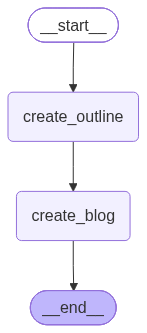

In [67]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())